# 1. Population

In [2]:
%run 00_shared.py

## Raw peek

In [3]:
xl_pop = pd.ExcelFile(f"{DATA_RAW}/Total Population_2020_3.xlsx")
print("Sheets:", xl_pop.sheet_names)

Sheets: ['Query_Total Pop', 'Sheet1']


In [4]:
pop = xl_pop.parse(xl_pop.sheet_names[0])
print(f"Shape: {pop.shape}")
pop.head(10)

Shape: (546, 4)


,Place,2020 Total Population,2010 Total Population,Percent Change
0,Maine,1362359,1328361,0.0
1,Androscoggin County,111139,107702,0.0
2,Aroostook County,67105,71870,-0.1
3,Cumberland County,303069,281674,0.1
4,Franklin County,29456,30768,-0.0
5,Hancock County,55478,54418,0.0
6,Kennebec County,123642,122151,0.0
7,Knox County,40607,39736,0.0
8,Lincoln County,35237,34457,0.0
9,Oxford County,57777,57833,-0.0


In [5]:
print(pop.dtypes)
print("\nNulls per column:")
print(pop.isnull().sum())

Place                     object
2020 Total Population      int64
2010 Total Population      int64
Percent Change           float64
dtype: object

Nulls per column:
Place                    0
2020 Total Population    0
2010 Total Population    0
Percent Change           5
dtype: int64


In [6]:
pop.describe(include="all")

,Place,2020 Total Population,2010 Total Population,Percent Change
count,546,546.0,546.0,541.0
unique,546,NaN,NaN,NaN
top,Maine,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,"7,485.5","7,297.6",0.0
std,NaN,"61,353.4","59,689.5",0.3
min,NaN,0.0,0.0,-0.5
25%,NaN,377.0,390.2,-0.1
50%,NaN,"1,172.0","1,187.0",-0.0
75%,NaN,"3,001.0","2,891.2",0.0


## 1a. Clean & Segment

In [12]:
pop = xl_pop.parse("Query_Total Pop")

pop_state    = pop[pop["Place"] == "Maine"].copy()
pop_counties = pop[pop["Place"].isin(MAINE_COUNTIES)].copy()
pop_munis    = pop[~pop["Place"].isin(["Maine"] + MAINE_COUNTIES)].copy()

print(f"State rows:   {len(pop_state)}")
print(f"County rows:  {len(pop_counties)}")
print(f"Municipality rows: {len(pop_munis)}")

pop_counties["Percent Change"] = pop_counties["Percent Change"] * 100

pop_counties.sort_values("2020 Total Population", ascending=False)

State rows:   1
County rows:  16
Municipality rows: 529


,Place,2020 Total Population,2010 Total Population,Percent Change
3,Cumberland County,303069,281674,7.6
16,York County,211972,197131,7.5
10,Penobscot County,152199,153923,-1.1
6,Kennebec County,123642,122151,1.2
1,Androscoggin County,111139,107702,3.2
2,Aroostook County,67105,71870,-6.6
9,Oxford County,57777,57833,-0.1
5,Hancock County,55478,54418,1.9
13,Somerset County,50477,52228,-3.4
7,Knox County,40607,39736,2.2


## 1b. County Population: 2010 vs 2020

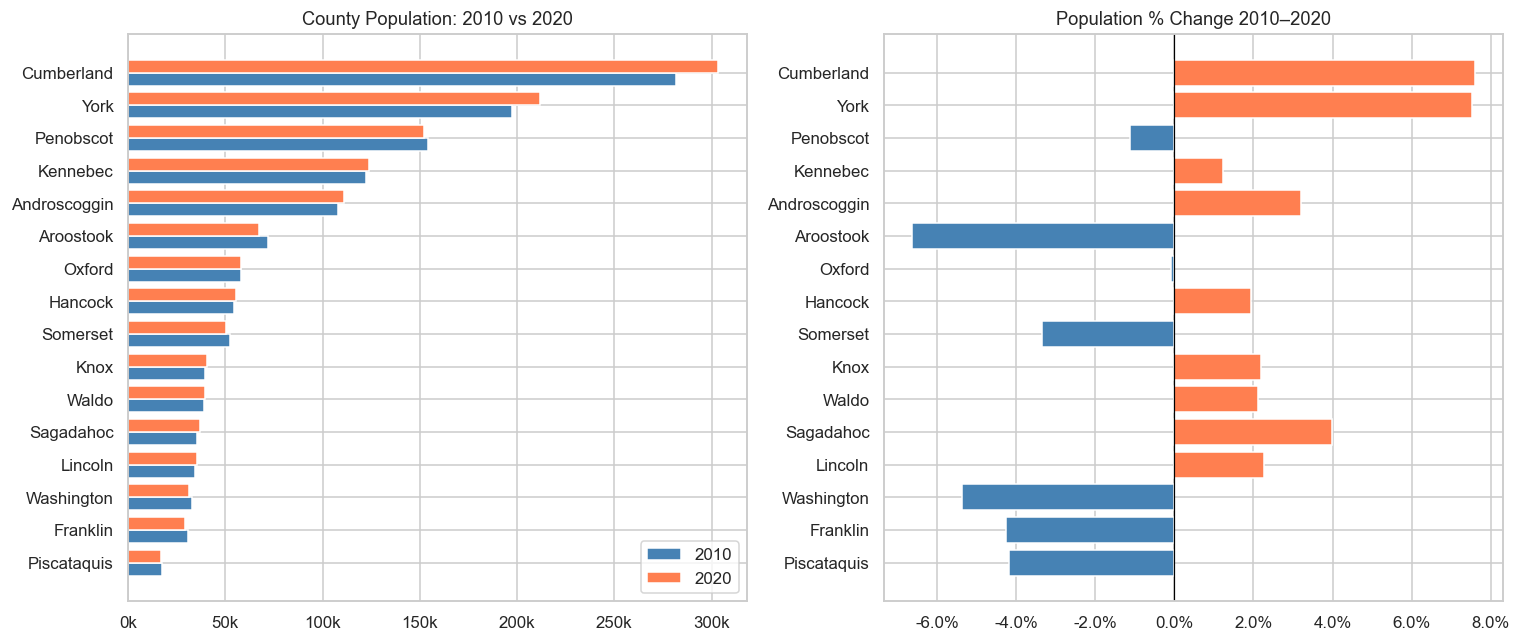


Maine state total: 1,362,359  (+2.56% vs 2010)


In [8]:
cty = pop_counties.sort_values("2020 Total Population")
short_names = [n.replace(" County", "") for n in cty["Place"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = range(len(cty))
w = 0.4
axes[0].barh([i - w/2 for i in x], cty["2010 Total Population"], height=w, label="2010", color="steelblue")
axes[0].barh([i + w/2 for i in x], cty["2020 Total Population"], height=w, label="2020", color="coral")
axes[0].set_yticks(list(x))
axes[0].set_yticklabels(short_names)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
axes[0].set_title("County Population: 2010 vs 2020")
axes[0].legend()

colors = ["coral" if v >= 0 else "steelblue" for v in cty["Percent Change"]]
axes[1].barh(short_names, cty["Percent Change"] * 100, color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}%"))
axes[1].set_title("Population % Change 2010\u20132020")

plt.tight_layout()
plt.show()

print(f"\nMaine state total: {pop_state['2020 Total Population'].values[0]:,}  "
      f"(+{pop_state['Percent Change'].values[0]*100:.2f}% vs 2010)")

## 1c. Municipality Growth: Top & Bottom 10

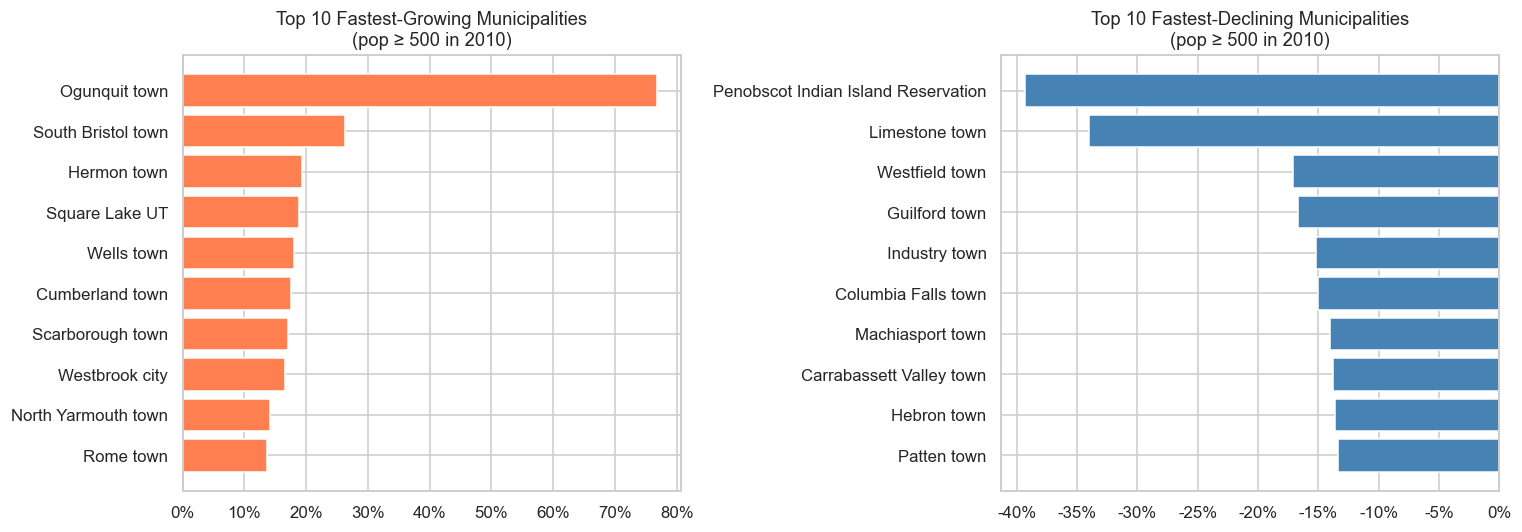


Top 10 growers:


,Place,2010 Total Population,2020 Total Population,pct_change
0,Ogunquit town,892,1577,76.8
1,South Bristol town,892,1127,26.3
2,Hermon town,5416,6461,19.3
3,Square Lake UT,594,706,18.9
4,Wells town,9589,11314,18.0
5,Cumberland town,7211,8473,17.5
6,Scarborough town,18919,22135,17.0
7,Westbrook city,17494,20400,16.6
8,North Yarmouth town,3565,4072,14.2
9,Rome town,1010,1148,13.7



Top 10 decliners:


,Place,2010 Total Population,2020 Total Population,pct_change
0,Penobscot Indian Island Reservation,610,370,-39.3
1,Limestone town,2314,1526,-34.1
2,Westfield town,549,455,-17.1
3,Guilford town,1521,1267,-16.7
4,Industry town,929,788,-15.2
5,Columbia Falls town,560,476,-15.0
6,Machiasport town,1119,962,-14.0
7,Carrabassett Valley town,781,673,-13.8
8,Hebron town,1416,1223,-13.6
9,Patten town,1017,881,-13.4


In [9]:
munis_sig = pop_munis[pop_munis["2010 Total Population"] >= 500].copy()
munis_sig["pct_change"] = munis_sig["Percent Change"] * 100

top10 = munis_sig.nlargest(10, "pct_change")[["Place", "2010 Total Population", "2020 Total Population", "pct_change"]]
bot10 = munis_sig.nsmallest(10, "pct_change")[["Place", "2010 Total Population", "2020 Total Population", "pct_change"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top10["Place"], top10["pct_change"], color="coral")
axes[0].set_title("Top 10 Fastest-Growing Municipalities\n(pop \u2265 500 in 2010)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
axes[0].invert_yaxis()

axes[1].barh(bot10["Place"], bot10["pct_change"], color="steelblue")
axes[1].set_title("Top 10 Fastest-Declining Municipalities\n(pop \u2265 500 in 2010)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nTop 10 growers:")
display(top10.reset_index(drop=True))
print("\nTop 10 decliners:")
display(bot10.reset_index(drop=True))

## Save

In [10]:
pd.to_pickle(
    {"pop_state": pop_state, "pop_counties": pop_counties, "pop_munis": pop_munis},
    f"{DATA_PROCESSED}/population.pkl"
)
print("Saved population.pkl")

Saved population.pkl
